In [13]:
import requests
import random
import json

In [15]:
# make up some analysis

n = 200

names = ['UV',"DLS","RAMAN"]
material = ["OGD",'W','W3','W10']
operateur = ['WL','LB','TB','LC','RS']
for i in range(n):

    m = random.choice(material)
    week = random.randint(1,55)
    sample = random.choice(['A','B','C','D','E','F','G','H'])
    code = f'{m}_{week}_{sample}'

    year = random.choice([2023,2024,2025])

    analysis = random.choice(names)
    if analysis == 'UV':
        path = f'Suivi_prod/CQ{year}/{m}/{str(year)[:-2]}{week}{sample}'
    elif analysis == 'RAMAN':
        path = f'Dossier_autre/{year}/{m}_{week}{sample}'
    else:
        path = f'Transfert_labo/{random.choice(operateur)}/{m}{str(year)[:-2]}{week}'

    data = {'Analyse_path_to_raw':path,
            'Analyse_code':code}
    
    url = 'http://127.0.0.1:8000/analyses/'
    headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'
    }

    response = requests.post(url, headers=headers, data=json.dumps(data))
    # print(response.json())

In [16]:
response.json()

{'Analyses_id': 200,
 'Analyse_path_to_raw': 'Suivi_prod/CQ2023/W3/205A',
 'Analyse_code': 'W3_5_A'}

In [17]:
# make up some matieres premieres

import random
import string

def generate_random_string(length=5):
    characters = string.ascii_letters + string.digits  # Includes A-Z, a-z, 0-9
    return ''.join(random.choices(characters, k=length))

def generate_code(nom):
    if nom == 'THF':
        return 'CW_001'
    elif nom == 'Carbone':
        return 'CW_002'
    else:
        return 'CW_003'
def apply_unit(nom):
    if nom == 'THF':
        return 'L'
    elif nom == 'Carbone':
        return 'kg'
    else:
        return 'kg'
    
for i in range(200):
    nom = random.choice(['THF','Carbone','Potassium'])
    data = {'MP_nom':nom,
            'MP_codeCW':generate_code(nom),
            'MP_ref_fournisseur':generate_random_string(length=20),
            'MP_date_reception':'2023-01-01',
            'MP_quantite':0,#random.randint(1,1000),
            'MP_unite':apply_unit(nom),
            'MP_Analyses':'codes_analyses_separated_by_commas'}
    
    url = 'http://127.0.0.1:8000/matieres_premieres/'
    headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'
    }

    response = requests.post(url, headers=headers, data=json.dumps(data))




In [19]:
# make up some KC8
import pandas as pd
import numpy as np
import random
import requests
import json

date_range = pd.date_range(start='2023-01-01', end='2025-01-10')

d = pd.DataFrame(requests.get('http://127.0.0.1:8000/matieres_premieres/', headers=headers).json())


for i in range(200):
    date = np.random.choice(date_range, replace=False)+pd.DateOffset(hours=0)
    debut = date + pd.DateOffset(hours=12)
    fin = debut + pd.DateOffset(hours=random.randint(1,3))
    nom = random.choice(['THF','Carbon','Potassium'])
    p = random.choice(d.loc[d.MP_nom == 'Potassium','MP_ref_fournisseur'].values)
    c = random.choice(d.loc[d.MP_nom == 'Carbone','MP_ref_fournisseur'].values)

    data = {"Batch_KC8_name": f"K{random.choice([23,24])}{random.randint(1, 55):02}",
            "Batch_KC8_date":str(date),
            "Batch_KC8_Technicien":random.choice(['WL','LB','TB','LC','RS']),
            "Batch_KC8_K_batch":p,
            "Batch_KC8_C_batch":c,
            "Batch_KC8_masse":random.choice([200,300]),
            "Batch_KC8_Temperature":random.choice([50,60,70]),
            "Batch_KC8_Agitation":random.choice([230,250,300]),
            "Batch_KC8_heure_debut":str(debut),
            "Batch_KC8_heure_fin":str(fin),
            "Batch_KC8_room_HR":random.randint(20,30),
            "Batch_KC8_room_T":random.randint(1,3)/10,
            "Batch_KC8_Analyses":'codes_analyses_separated_by_commas'}
    
    url = 'http://127.0.0.1:8000/KC8/'
    headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'
    }

    response = requests.post(url, headers=headers, data=json.dumps(data))
    
    

In [ ]:
response.content

b'{"Batch_KC8_id":200,"Batch_KC8_name":"K2410","Batch_KC8_date":"2023-05-26T00:00:00","Batch_KC8_Technicien":"TB","Batch_KC8_K_batch":"yjFYTJY3WCkE3iM6UvEc","Batch_KC8_C_batch":"WOJrkztV7r4yEWL5ThtW","Batch_KC8_masse":300,"Batch_KC8_Temperature":50.0,"Batch_KC8_Agitation":250,"Batch_KC8_heure_debut":"2023-05-26T12:00:00","Batch_KC8_heure_fin":"2023-05-26T13:00:00","Batch_KC8_room_HR":28.0,"Batch_KC8_room_T":0.1,"Batch_KC8_Analyses":"codes_analyses_separated_by_commas"}'

In [ ]:
response = requests.get('http://127.0.0.1:8000/KC8/', headers=headers)

In [ ]:
headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'
    }
d = pd.DataFrame(requests.get('http://127.0.0.1:8000/KC8/', headers=headers).json())


In [ ]:
# make up some OGD
import pandas as pd
import numpy as np
import random
import requests
import json

date_range = pd.date_range(start='2023-01-01', end='2025-01-10')
headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'
    }
d = pd.DataFrame(requests.get('http://127.0.0.1:8000/KC8/', headers=headers).json())


for i in range(200):
    date = np.random.choice(date_range, replace=False)+pd.DateOffset(hours=0)
    debut = date + pd.DateOffset(hours=12)
    fin = debut + pd.DateOffset(days=6)
    nom = random.choice(['THF','Carbon','Potassium'])
    p = random.choice(d.loc[:,'Batch_KC8_name'].values)

    data = {"Batch_OGD_name": f"OGD{random.choice([23,24])}{random.randint(1, 55):02}{random.choice(['A','B','C','D'])}",
            "Batch_OGD_date":str(date),
            "Batch_OGD_Technicien":random.choice(['WL','LB','TB','LC','RS']),
            "Batch_OGD_KC8_batch":p,
            "Batch_OGD_KC8_masse":20,
            "Batch_OGD_THF_batch":generate_random_string(),
            "Batch_OGD_THF_Volume":random.choice([300,400]),
            "Batch_OGD_Temperature":random.choice([50,60,70]),
            "Batch_OGD_Agitation":random.choice([230,260,300]),
            "Batch_OGD_heure_debut":str(debut),
            "Batch_OGD_heure_fin":str(fin),
            "Batch_OGD_room_HR":random.randint(20,30),
            "Batch_OGD_room_T":random.randint(1,3)/10,
            "Batch_OGD_Analyses":'codes_analyses_separated_by_commas'}
    
    url = 'http://127.0.0.1:8000/OGD/'
    headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'
    }

    response = requests.post(url, headers=headers, data=json.dumps(data))


In [ ]:
response

<Response [200]>

In [ ]:
# make up some envoi
import pandas as pd
import numpy as np
import random
import requests
import json


date_range = pd.date_range(start='2023-01-01', end='2025-01-10')
headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'
    }

for i in range(5):
    date = np.random.choice(date_range, replace=False)
    date_prevu = date+pd.DateOffset(days=random.randint(10,16))
  
    nom = random.choice(['client1','Client2','client3'])
    p = random.choice(['W2','W2NC','W3','W3NC','W10','W10NC','EpoF','EpoC'])
    emb = random.choice(['sac','bouteille','fiole','bidon'])

    data = {"Envoi_date_commande":str(date),
            "Envoi_client_name":nom,
            "Envoi_produit_name":p,
            "Envoi_produit_batch":None,
            "Envoi_produit_Qte":random.randint(3,12),
            "Envoi_produit_emballage":emb,
            "Envoi_date_prevu":str(date_prevu),
            "Envoi_date_effective":None,
            "Envoi_code_coli":None,
            "Envoi_retour_client":None,
            }
    
    url = 'http://127.0.0.1:8000/Envoi/'
    headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'
    }

    response = requests.post(url, headers=headers, data=json.dumps(data))


In [ ]:
response.content

b'{"Envoi_id":5,"Envoi_date_commande":"2023-04-15T00:00:00","Envoi_client_name":"client3","Envoi_produit_name":"W10NC","Envoi_produit_batch":null,"Envoi_produit_Qte":4.0,"Envoi_produit_emballage":"bouteille","Envoi_date_prevu":"2023-04-29T00:00:00","Envoi_date_effective":null,"Envoi_code_coli":null,"Envoi_delivered":false,"Envoi_retour_client":null}'

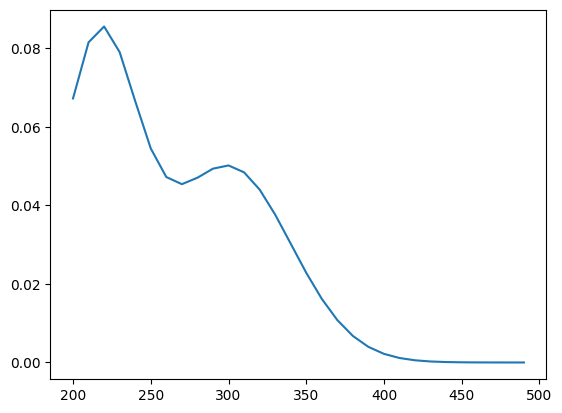

In [ ]:
# make up some UV analyse

    # get OGD batch names
import requests
headers = {
'accept': 'application/json',
'Content-Type': 'application/json'
}
response = requests.get('http://127.0.0.1:8000/OGD/', headers=headers)
OGDs = [a['Batch_OGD_name'] for a in response.json()]

    # create cruves
from scipy import stats 
import matplotlib.pyplot as plt

def make_curve():
    # Generate the data
    array1 = stats.norm.pdf(range(10, 40), random.choice(np.arange(10,12,0.2)), random.choice(np.arange(2,3,0.1)))
    array2 = stats.norm.pdf(range(30), 10, random.choice(np.arange(2,5,0.2)))

    # Reshape the arrays to 2D (add an extra axis)
    array1 = array1.reshape(1, -1)  # Shape: (1, n)
    array2 = array2.reshape(1, -1)  # Shape: (1, n)

    # Concatenate along axis=1
    result = np.concatenate([array1, array2]).T
    return result.mean(axis=1)

plt.plot(np.arange(200,500,10),make_curve())
curve = {str(x): y for x, y in zip(np.arange(200,500,10),make_curve())}

    # populate db
for i, name in enumerate(OGDs):

    curve = {str(x): y for x, y in zip(np.arange(200,500,10),make_curve())}
    data=dict({'Analyses_UV_id' : i,
            'Analyse_UV_name' : name,
            'Analyse_UV_subname' : 'UV',
            'Analyse_UV_details' : {'dillution':'1:10','centrifuge':random.choice([True,False])},
            'Analyses_UV_data' :curve})
    response = requests.post('http://127.0.0.1:8000/analyses_UV/', headers=headers,data=json.dumps(data))
    # break

In [ ]:
# make up some raman analysis



In [22]:
from scipy import stats 
import matplotlib.pyplot as plt

# Generate the data
array1 = stats.norm.pdf(range(1200, 1300), random.choice(np.arange(10,12,0.2)), random.choice(np.arange(2,3,0.1)))
array2 = stats.norm.pdf(range(2400, 2600), 10, random.randint(2, 5))

# Reshape the arrays to 2D (add an extra axis)
array1 = array1.reshape(1, -1)  # Shape: (1, n)
array2 = array2.reshape(1, -1)  # Shape: (1, n)

# Concatenate along axis=1
result = np.concatenate([array1, array2]).T

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 100 and the array at index 1 has size 200

In [ ]:
total_length = 3000 - 800 + 1  # From 800 to 3000 inclusive
padded_array1 = np.zeros(total_length)
padded_array2 = np.zeros(total_length)
padded_array1[1200-800:1300-800] = array1
padded_array2[2400-800:2600-800] = array2
padded_array1 = padded_array1.reshape(1, -1)  # Shape: (1, total_length)
padded_array2 = padded_array2.reshape(1, -1)  # Shape: (1, total_length)
result = np.concatenate([padded_array1, padded_array2])


np.int64(1356)

np.float64(2.3000000000000003)

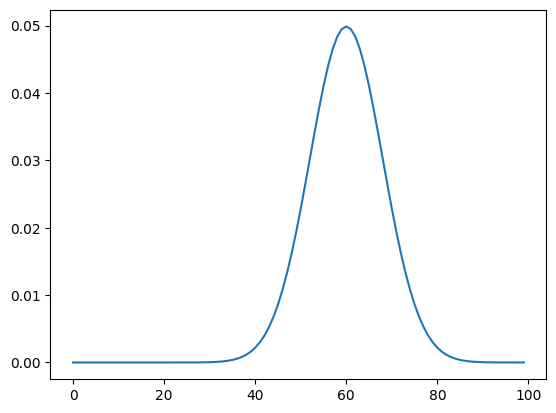

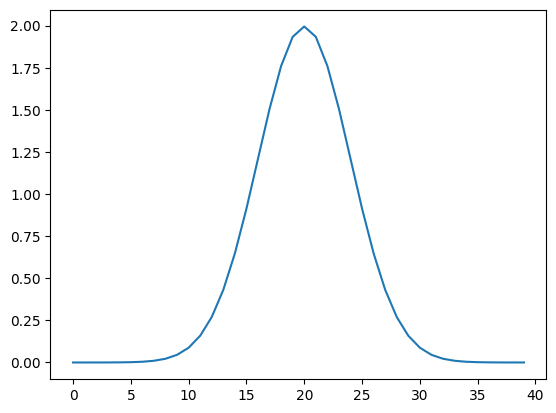

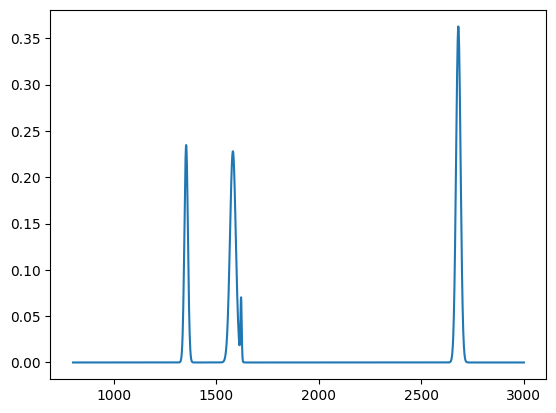

In [387]:
import numpy as np
from scipy import stats
import random


def generate_raman():
    # Generate the arrays
    array1 = 5* stats.norm.pdf(range(1300, 1400), random.choice(np.arange(1345, 1365, 1)), random.choice(np.arange(8, 10, 0.5)))
    array2 = 8* stats.norm.pdf(range(1500, 1660), 1580, random.randint(10, 20))
    array3 = 0.5*stats.norm.pdf(range(1580, 1660), 1620, random.randint(2, 5))
    array4 = 10*stats.norm.pdf(range(2500, 2800), 2680, random.randint(8, 12))

    # Determine the total length needed
    total_length = 3000 - 800 + 1  # From 800 to 3000 inclusive

    # Create zero-padded arrays of the total length
    padded_array1 = np.zeros(total_length)
    padded_array2 = np.zeros(total_length)
    padded_array3 = np.zeros(total_length)
    padded_array4 = np.zeros(total_length)

    # Insert the original arrays into the padded arrays at the correct positions
    padded_array1[1300-800:1400-800] = array1
    padded_array2[1500-800:1660-800] = array2
    padded_array3[1580-800:1660-800] = array3
    padded_array4[2500-800:2800-800] = array4

    # Reshape the arrays to 2D (add an extra axis)
    padded_array1 = padded_array1.reshape(1, -1)  # Shape: (1, total_length)
    padded_array2 = padded_array2.reshape(1, -1)  # Shape: (1, total_length)
    padded_array3 = padded_array3.reshape(1, -1)  # Shape: (1, total_length)
    padded_array4 = padded_array4.reshape(1, -1)  # Shape: (1, total_length)

    # Concatenate along axis=1 and transpose
    result = np.concatenate([padded_array1, padded_array2,padded_array3,padded_array4]).T
    return np.sum(result,axis=1)
plt.plot(range(800,3001),generate_raman())


In [ ]:
x = np.linspace(-50,50, 100)
y1 = stats.norm.pdf(x,0,10)*100
y2 = stats.norm.pdf(x,0,20)*200



In [ ]:
# make up some clients

n=10

client = ['Client 1 ',
          'Client 1 UK',
          'Client 1 Italy',
          'Client 2',
          'Client 3',
          'Client 4 Site 1',
          'Client 4 Site 2']
adresse = ['ZA Jolimont, 81200, Mazamet, France',
           'Port of England, 728837, London, United Kingdom',
           'Maque products, 887F73, Napoli, Italy'
           'ZI CHaumont, 33230, Bordeaux, France',
           'Bat Cheminnov, 74300, Bladebli, France',
           'Compositadour, 21000, Bayonne, France',
            'Compositadour recycling, 21000, Bayonne, France']
url = 'http://127.0.0.1:8000/Client/'
headers = {
'accept': 'application/json',
'Content-Type': 'application/json'
}

for i,j in zip(client,adresse):
    data = {'Client_nom':i,
            'Client_adresse':j}
    response = requests.post(url, headers=headers, data=json.dumps(data))
